# Lead Scoring — Data Security Software

A lead-scoring model built on synthetic data shaped by 4 years of real SDR experience at a data security software vendor (APAC, end-user segment). The goal: predict which incoming leads are worth an SDR's time, using only information available the moment a lead enters an SDR's visibility zone (crosses the `lead_score` threshold) — before any human has touched it.

**Approach:** exploratory data analysis → leakage-aware feature engineering → Logistic Regression and XGBoost, compared on PR-AUC given a ≈2.4% positive rate → feature importance checked against real SDR domain knowledge → business economics translated into a gains/lift table.

Data: `data/leads.csv` (one row per materialized lead) and `data/lead_activities.csv` (one row per activity, many-to-one with leads). 

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("data/leads.csv", parse_dates=["created_at"])
activities = pd.read_csv("data/lead_activities.csv", parse_dates=["activity_timestamp"])

print(df.shape, activities.shape)
df.head()

(15000, 32) (22818, 4)


,lead_id,created_at,first_name,last_name,email,region,country,industry,company_size_bucket,job_title_seniority,lead_source_channel,originating_activity,product_family,product,lead_score_at_creation,lead_type_at_creation,lead_type_current,site_visits_before_action,pages_viewed,days_since_first_touch,converted_to_opportunity,funnel_stage,closed_won,disqualified_reason,lead_score_current,license_count,modules_in_deal,owner_id,owner_role,deal_amount,payment_doc_attached,sdr_call_attempts
0,1,2021-03-12,Olivia,Martinez,olivia.martinez@company493436.com,NaN,South Africa,Manufacturing,201-1000,director,event,Free Community Edition: DataSec Auditor for Ac...,Auditor,DataSec Auditor for Active Directory: Free Com...,15,end_user,end_user,4,7,0,0,Working - In Progress (Contacted),0,NaN,15,NaN,NaN,SDR_08,sdr,NaN,NaN,5
1,2,2021-03-05,Zoe,Jackson,zoe.jackson@company213652.com,APAC,India,NaN,51-200,NaN,paid,Free Community Edition: DataSec Auditor for Wi...,Auditor,DataSec Auditor for Windows File Servers: Free...,15,end_user,NaN,3,5,8,0,Working - No Contact,0,NaN,15,NaN,NaN,SDR_07,sdr,NaN,NaN,5
2,3,2020-09-03,Hiroshi,Clark,hiroshi.clark@company335025.com,APAC,Philippines,Other,201-1000,individual_contributor,organic,Free Trial: DataSec Classification for Nutanix...,Data Classification,DataSec Classification for Nutanix Files,40,msp,msp,4,11,2,0,Working - In Progress (Contacted),0,NaN,48,NaN,NaN,SDR_05,sdr,NaN,NaN,4
3,4,2021-03-04,Ella,Moore,ella.moore@company476339.com,EMEA,Sweden,Finance,1000+,NaN,paid,Free Trial: DataSec Classification for Nutanix...,Data Classification,DataSec Classification for Nutanix Files,40,NaN,end_user,5,11,2,1,Closed Lost,0,NaN,40,150.0,1.0,SDR_09,sdr,NaN,NaN,10
4,5,2021-05-03,Yuki,Lewis,yuki.lewis@company181835.com,APAC,India,Other,201-1000,director,paid,Launch In-Browser Demo: DataSec Classification...,Data Classification,DataSec Classification for SharePoint,15,end_user,end_user,5,16,4,1,Closed Lost,0,NaN,15,150.0,1.0,SDR_01,sdr,NaN,NaN,9


In [3]:
activities.head()

,lead_id,activity_timestamp,activity_value,points
0,1,2021-03-12,Free Community Edition: DataSec Auditor for Ac...,15
1,2,2021-03-05,Free Community Edition: DataSec Auditor for Wi...,15
2,3,2020-09-03,Free Trial: DataSec Classification for Nutanix...,40
3,3,2020-09-08,DataSec Password Expiration Notifier,8
4,4,2021-03-04,Free Trial: DataSec Classification for Nutanix...,40


## 1. Data Loading and Initial Inspection

`lead_id` is the join key between the two tables — one row per lead in `leads.csv`, many rows per lead in `lead_activities.csv`. First step before any analysis: drop the PII columns (`first_name`, `last_name`, `email`). Even on synthetic data, this mirrors real practice on a real CRM export — PII shouldn't sit in a working analysis dataframe a moment longer than necessary.

In [4]:
pii_columns = ["first_name", "last_name", "email"]
assert all(col in df.columns for col in pii_columns)
df = df.drop(columns=pii_columns)
print("Dropped PII columns:", pii_columns)

Dropped PII columns: ['first_name', 'last_name', 'email']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   lead_id                    15000 non-null  int64         
 1   created_at                 15000 non-null  datetime64[us]
 2   region                     14260 non-null  str           
 3   country                    13861 non-null  str           
 4   industry                   11539 non-null  str           
 5   company_size_bucket        12134 non-null  str           
 6   job_title_seniority        10735 non-null  str           
 7   lead_source_channel        13866 non-null  str           
 8   originating_activity       15000 non-null  str           
 9   product_family             15000 non-null  str           
 10  product                    15000 non-null  str           
 11  lead_score_at_creation     15000 non-null  int64         
 12  lead_type_at_cr

In [6]:
print("Shape:", df.shape)

Shape: (15000, 29)


In [7]:
print("\nColumn types:\n", df.dtypes)


Column types:
 lead_id                               int64
created_at                   datetime64[us]
region                                  str
country                                 str
industry                                str
company_size_bucket                     str
job_title_seniority                     str
lead_source_channel                     str
originating_activity                    str
product_family                          str
product                                 str
lead_score_at_creation                int64
lead_type_at_creation                   str
lead_type_current                       str
site_visits_before_action             int64
pages_viewed                          int64
days_since_first_touch                int64
converted_to_opportunity              int64
funnel_stage                            str
closed_won                            int64
disqualified_reason                     str
lead_score_current                    int64
license_count   

## 2. Exploratory Data Analysis

Starting point: understand the target's base rate and the shape of the funnel before touching any modeling decision — the low base rate found here drives every choice from Step 4 onward (metric choice, class-imbalance handling, threshold selection).

In [8]:
print("Lead-level Closed Won rate:", df["closed_won"].mean())
print("Qualification rate (lead -> opportunity):", df["converted_to_opportunity"].mean())
opportunities = df[df["converted_to_opportunity"] == 1]
print("Win rate among opportunities:", opportunities["closed_won"].mean())

Lead-level Closed Won rate: 0.023733333333333332
Qualification rate (lead -> opportunity): 0.20833333333333334
Win rate among opportunities: 0.11392


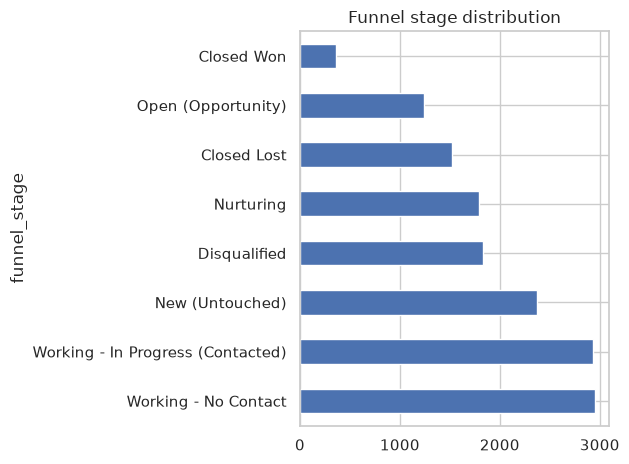

In [9]:
df["funnel_stage"].value_counts().plot(kind="barh")
plt.title("Funnel stage distribution")
plt.tight_layout()
plt.show()

**Funnel shape:** leads thin out steadily through the pipeline — 2,948 sit in `Working - No Contact` and 2,929 in `Working - In Progress (Contacted)`, 2,374 are still `New (Untouched)` (not yet worked at all), 1,829 end `Disqualified`, and 1,795 sit in `Nurturing`. Only 1,243 ever reach `Open (Opportunity)`, and of those, just 356 end in `Closed Won` — a realistic SDR funnel shape, not a uniform or artificially clean drop-off.

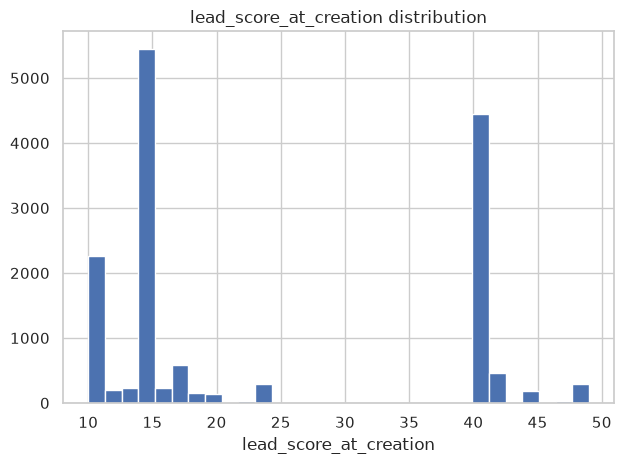

In [10]:
df["lead_score_at_creation"].hist(bins=30)
plt.title("lead_score_at_creation distribution")
plt.xlabel("lead_score_at_creation")
plt.tight_layout()
plt.show()

**Score distribution:** `lead_score_at_creation` ranges from 10 (the visibility threshold itself — nothing below it ever materializes into a lead) to 49, with a strong cluster at 15 (both the median and the 25th percentile sit there). The single most common way to cross the threshold is one warm action worth 15 points (a Free Community Edition download or an in-browser demo request) rather than accumulating several smaller ones.

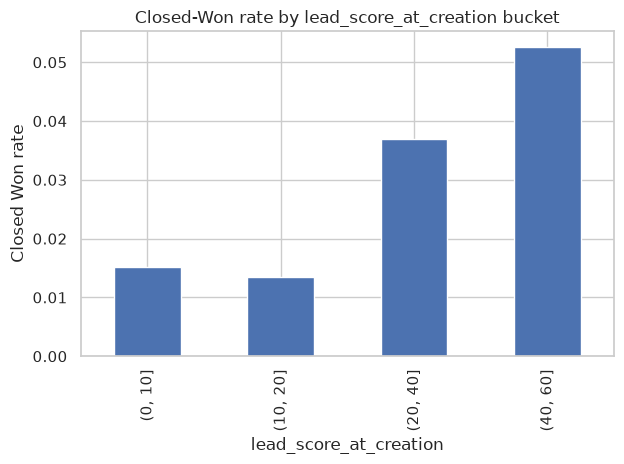

In [11]:
score_bucket = pd.cut(df["lead_score_at_creation"], bins=[0, 10, 20, 40, 60, 1000])
df.groupby(score_bucket, observed=True)["closed_won"].mean().plot(kind="bar")
plt.title("Closed-Won rate by lead_score_at_creation bucket")
plt.ylabel("Closed Won rate")
plt.tight_layout()
plt.show()

**Higher score → higher win rate, mostly.** Win rate climbs from 1.35% in the (10, 20] bucket to 3.70% in (20, 40] and 5.26% in (40, 60] — score is doing real work. The one wrinkle: the lowest bucket, (0, 10], actually edges out (10, 20] slightly (1.51% vs. 1.35%) — a small non-monotonic dip worth noting rather than smoothing over, though it doesn't change the overall picture that score is a genuinely useful signal.

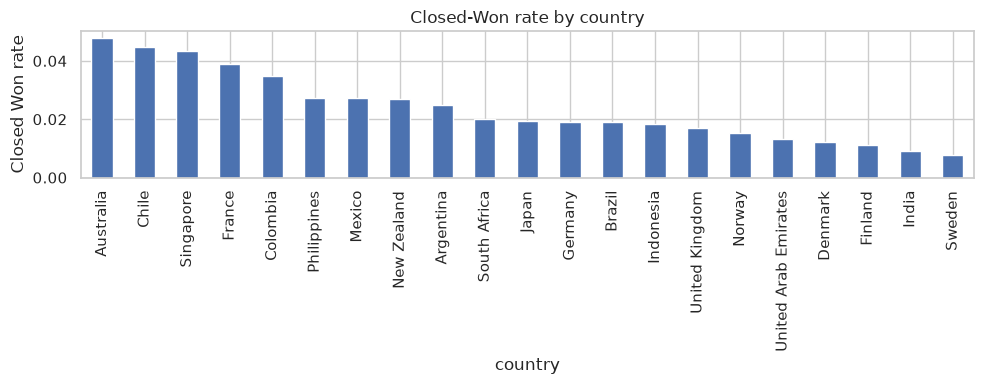

country
Australia               0.047758
Chile                   0.044706
Singapore               0.043254
France                  0.039106
Colombia                0.034913
Philippines             0.027245
Mexico                  0.027228
New Zealand             0.026887
Argentina               0.024876
South Africa            0.020073
Japan                   0.019547
Germany                 0.019197
Brazil                  0.019093
Indonesia               0.018349
United Kingdom          0.017036
Norway                  0.015280
United Arab Emirates    0.013258
Denmark                 0.012048
Finland                 0.011257
India                   0.009091
Sweden                  0.007707
Name: closed_won, dtype: float64


In [12]:
won_rate_by_country = df.groupby("country")["closed_won"].mean().sort_values(ascending=False)
won_rate_by_country.plot(kind="bar", figsize=(10, 4))
plt.title("Closed-Won rate by country")
plt.ylabel("Closed Won rate")
plt.tight_layout()
plt.show()
print(won_rate_by_country)

**Country breakdown confirms real SDR experience:** `Australia` tops the list at 4.78% and `Sweden` sits at the bottom at 0.77%, with `India` (0.91%) and the rest of the Nordics (`Finland` 1.13%, `Denmark` 1.20%, `Norway` 1.53%) also clustered low — exactly the pattern from personal SDR experience (India converts far below average, Australia well above, Nordic buyers stay private about budget/authority). This gets confirmed independently by the model's own feature importances in Step 5.

### Missing values

In [13]:
df.isna().sum().sort_values(ascending=False)

deal_amount                  14644
payment_doc_attached         14644
disqualified_reason          13171
license_count                11875
modules_in_deal              11875
lead_type_current             5322
job_title_seniority           4265
industry                      3461
lead_type_at_creation         2996
company_size_bucket           2866
country                       1139
lead_source_channel           1134
region                         740
lead_score_at_creation           0
product                          0
product_family                   0
originating_activity             0
lead_id                          0
created_at                       0
pages_viewed                     0
site_visits_before_action        0
closed_won                       0
funnel_stage                     0
converted_to_opportunity         0
days_since_first_touch           0
owner_id                         0
lead_score_current               0
owner_role                       0
sdr_call_attempts   

#### MNAR detection for missing values

In [14]:
gap_cols = [
    "region", "country", "industry", "company_size_bucket",
    "job_title_seniority", "lead_source_channel", "lead_type_at_creation",
]

rows = []
for col in gap_cols:
    is_null = df[col].isna()
    rows.append({
        "column": col,
        "n_missing": is_null.sum(),
        "pct_missing": is_null.mean(),
        "closed_won_missing": df.loc[is_null, "closed_won"].mean(),
        "closed_won_present": df.loc[~is_null, "closed_won"].mean(),
    })

missingness_report = pd.DataFrame(rows).set_index("column")
missingness_report["rate_ratio"] = (
    missingness_report["closed_won_missing"] / missingness_report["closed_won_present"]
)
missingness_report

,n_missing,pct_missing,closed_won_missing,closed_won_present,rate_ratio
column,,,,,
region,740,0.049333,0.021622,0.023843,0.906836
country,1139,0.075933,0.016681,0.024313,0.686111
industry,3461,0.230733,0.021092,0.024526,0.860009
company_size_bucket,2866,0.191067,0.018144,0.025054,0.724198
job_title_seniority,4265,0.284333,0.018288,0.025897,0.706208
lead_source_channel,1134,0.075600,0.022928,0.023799,0.963380
lead_type_at_creation,2996,0.199733,0.023698,0.023742,0.998154


In [15]:
from scipy.stats import chi2_contingency

chi2_rows = []
for col in gap_cols:
    is_null = df[col].isna()
    n_miss = is_null.sum()
    n_pres = (~is_null).sum()
    won_miss = df.loc[is_null, "closed_won"].sum()
    won_pres = df.loc[~is_null, "closed_won"].sum()
    table = [[won_miss, n_miss - won_miss], [won_pres, n_pres - won_pres]]
    _, p_value, _, _ = chi2_contingency(table, correction=True)
    chi2_rows.append({"column": col, "p_value": p_value})

chi2_report = pd.DataFrame(chi2_rows).set_index("column")
bonferroni_alpha = 0.05 / len(gap_cols)
chi2_report["significant_at_0.05"] = chi2_report["p_value"] < 0.05
chi2_report["significant_bonferroni"] = chi2_report["p_value"] < bonferroni_alpha

missingness_report = missingness_report.join(chi2_report)
missingness_report

,n_missing,pct_missing,closed_won_missing,closed_won_present,rate_ratio,p_value,significant_at_0.05,significant_bonferroni
column,,,,,,,,
region,740,0.049333,0.021622,0.023843,0.906836,0.792388,False,False
country,1139,0.075933,0.016681,0.024313,0.686111,0.127190,False,False
industry,3461,0.230733,0.021092,0.024526,0.860009,0.271253,False,False
company_size_bucket,2866,0.191067,0.018144,0.025054,0.724198,0.034216,True,False
job_title_seniority,4265,0.284333,0.018288,0.025897,0.706208,0.006893,True,True
lead_source_channel,1134,0.075600,0.022928,0.023799,0.963380,0.933118,False,False
lead_type_at_creation,2996,0.199733,0.023698,0.023742,0.998154,1.000000,False,False


#### Missingness vs. closed_won — findings

All seven columns show `rate_ratio < 1`: leads with a missing value convert at a lower rate than leads with the field filled in, consistently in the same direction. That said, the effect size varies a lot, and with a base rate this low (2.37%) direction alone isn't enough — I ran a chi-square test on each column to separate signal from noise.

Two columns are statistically significant at α=0.05: `job_title_seniority` (p=0.007) and `company_size_bucket` (p=0.034). `job_title_seniority` even survives a Bonferroni correction for testing 7 columns at once (α=0.05/7≈0.0071); `company_size_bucket` does not, so I'm treating that one as a weaker signal. The remaining five columns (`region`, `country`, `industry`, `lead_source_channel`, `lead_type_at_creation`) show the same direction but aren't distinguishable from noise at this sample size.

**Decision:** `job_title_seniority` and `company_size_bucket` get an explicit `_is_missing` flag before imputation — the fact that they're missing carries information beyond what an `"Unknown"` category alone captures for a linear model. The other five get imputed straight to `"Unknown"` with no flag.

**Open question for later:** since the direction is the same across every column, missingness might not be about any one specific field — it could be that leads with sparser profiles overall convert worse. Worth checking `closed_won` against the count of missing fields per lead as a follow-up.

#### Missing-value imputation strategy

Applying the flag-vs-impute decision from the findings above: `job_title_seniority` and `company_size_bucket` get an explicit missingness flag, the rest are imputed to `"Unknown"`.

In [16]:
missing_strategy = {
    "region": "impute",
    "country": "impute",
    "industry": "impute",
    "company_size_bucket": "flag",
    "job_title_seniority": "flag",
    "lead_source_channel": "impute",
    "lead_type_at_creation": "impute",
}

def apply_missing_strategy(frame: pd.DataFrame, strategy: dict[str, str]) -> pd.DataFrame:
    frame = frame.copy()
    for col, action in strategy.items():
        if action == "flag":
            frame[f"{col}_is_missing"] = frame[col].isna().astype(int)
        frame[col] = frame[col].fillna("Unknown")
    return frame

df_imputed = apply_missing_strategy(df, missing_strategy)
df_imputed[gap_cols].isna().sum()

region                   0
country                  0
industry                 0
company_size_bucket      0
job_title_seniority      0
lead_source_channel      0
lead_type_at_creation    0
dtype: int64

## 3. Feature Engineering

Every column in `leads.csv` and `lead_activities.csv` is sorted into one of four buckets — feature, leakage, fairness/attribution problem, or PII — based on what's genuinely knowable the moment a lead enters the SDR's visibility zone, not just what's technically present in the table.

### Feature classification

**Feature** — known at the moment the lead enters the SDR's visibility zone (crosses the `lead_score` threshold):
- `region`, `country`, `industry`, `company_size_bucket` (+ `company_size_bucket_is_missing`), `job_title_seniority` (+ `job_title_seniority_is_missing`), `lead_source_channel` — the demographic/firmographic fields (Step 2 flag/impute decision applies here)
- `product_family` — structured helper column, always populated, derived from the triggering activity. (`product`, the more specific sibling column, is available too but held out of `X` below — high-cardinality and redundant with `product_family` plus the engineered activity-tier counts.)
- `lead_type_at_creation` — the SDR's pre-call desk-research guess, filled before any contact
- `lead_score_at_creation` — CRM score frozen at the moment the lead crossed the visibility threshold and entered the SDR's queue
- `site_visits_before_action`, `pages_viewed`, `days_since_first_touch` — engagement metrics as of the triggering activity
- Engineered from `lead_activities.csv`: `num_hot_actions`, `num_warm_actions`, `num_cool_actions`, `num_cold_actions`, `total_actions` — **but only counting activities with `activity_timestamp <= created_at`**. `created_at` here is not "first touch": a generic CRM materializes a Lead record on any single web-form action (a demo request and a lone collateral download both create a Lead row immediately), but SDR can only see the lead in the pipeline once cumulative `lead_score` first crosses the 10-point visibility threshold — `created_at` *is* that threshold-crossing moment, the same instant `originating_activity` happened. An unfiltered count would leak `lead_score_current`'s information back in through the side door.

**Leakage** — only known after the lead has already entered the SDR's queue:
- `lead_type_current` — corrected only after the SDR's qualification call
- `lead_score_current` — keeps accumulating with post-creation nurture activity
- `funnel_stage`, `converted_to_opportunity`, `disqualified_reason` — describe what happened *while working* the lead
- `license_count`, `modules_in_deal`, `deal_amount`, `payment_doc_attached` — only exist once an opportunity is created/closed
- `sdr_call_attempts` — accumulates as the SDR works the lead, rises specifically once it's converted

**Fairness/attribution problem:**
- `owner_id` — knowable early, but scoring by it rewards "assigned to a strong rep," not lead quality
- `owner_role` — same fairness issue, *and* it's also leakage by timing: it's only decided once the opportunity already exists (MSP/reseller → RM, or >150-license handoff), so it isn't even available when the lead enters the queue

**PII / not a feature:**
- `first_name`, `last_name`, `email` — already dropped
- `lead_id`, `created_at` — identifiers/timestamps, not model inputs (though `created_at` is needed to filter `activities` above)
- `originating_activity` — technically knowable the moment the lead enters the queue, but it's the free-text activity string that `product_family`/`product` and the tier counts already structure — kept out of `X` as redundant/high-cardinality rather than for a leakage or fairness reason
- `closed_won` — the target, not a feature

In [17]:
assert {"job_title_seniority_is_missing", "company_size_bucket_is_missing"} <= set(df_imputed.columns), (
    "run/rerun the missing_strategy cell above with 'flag' for company_size_bucket "
    "and job_title_seniority first"
)

from src.lead_constants import classify_activity_tier

activities_with_created = activities.merge(df_imputed[["lead_id", "created_at"]], on="lead_id")
pre_creation = activities_with_created[
    activities_with_created["activity_timestamp"] <= activities_with_created["created_at"]
].copy()

reconstructed_score = pre_creation.groupby("lead_id")["points"].sum()
true_score = df_imputed.set_index("lead_id")["lead_score_at_creation"].loc[reconstructed_score.index]
assert (reconstructed_score == true_score).all(), (
    "pre-creation activity points don't reconstruct lead_score_at_creation exactly — "
    "the activity_timestamp <= created_at cutoff doesn't match the real visibility-threshold boundary"
)

pre_creation["tier"] = pre_creation["activity_value"].apply(classify_activity_tier)

tier_counts = (
    pre_creation
    .pivot_table(index="lead_id", columns="tier", values="activity_value", aggfunc="count", fill_value=0)
)
for tier in ("hot", "warm", "cool", "cold"):
    if tier not in tier_counts.columns:
        tier_counts[tier] = 0
tier_counts = tier_counts[["hot", "warm", "cool", "cold"]].rename(columns=lambda t: f"num_{t}_actions")
tier_counts["total_actions"] = tier_counts.sum(axis=1)

engineered_columns = [
    "num_hot_actions", "num_warm_actions", "num_cool_actions", "num_cold_actions", "total_actions",
]
df_imputed = df_imputed.merge(tier_counts, on="lead_id", how="left")
df_imputed[engineered_columns] = df_imputed[engineered_columns].fillna(0)
df_imputed[engineered_columns].describe()

,num_hot_actions,num_warm_actions,num_cool_actions,num_cold_actions,total_actions
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.361333,0.432667,0.312133,0.178000,1.284133
std,0.480403,0.495462,0.551779,0.435196,0.513633
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,2.000000
max,1.000000,1.000000,2.000000,4.000000,5.000000


**Leakage boundary, verified, not assumed:** the assertion above passed for all 15,000 leads — summing the points of every activity at or before `created_at` reconstructs `lead_score_at_creation` exactly. This confirms `created_at` is genuinely the visibility-threshold-crossing moment, not a generic "lead first showed up" timestamp — in a typical CRM, a single collateral download alone would create a Lead record immediately; here, a contact only becomes a Lead once enough activity (or one hot action) pushes cumulative score past 10 points, and that's exactly the boundary this cutoff respects.

**What the output shows:** `total_actions` has mean 1.28, median 1, max 5 — most materialized leads have only 1-2 pre-creation activities. That lines up with the same threshold mechanic: a single hot action (40 pts) crosses the 10-point visibility bar by itself, so one activity is often enough to become a Lead record. `num_hot_actions` and `num_warm_actions` cap at 1 in this data (their 75th percentile is already 1), while `num_cold_actions` goes up to 4 — consistent with the "pile of cold collateral downloads that together cross the threshold, even though none individually was hot" case the spec calls out as a noisy proxy for real intent.

**Conclusion:** these five columns will likely correlate strongly with `lead_score_at_creation` (same underlying activities, different aggregation) — worth watching for in Step 5's feature importance, since collinearity can distort a linear model's coefficients even when the prediction itself is fine.

### Building the feature matrix and train/test split

In [18]:
target = "closed_won"

categorical_columns = [
    "product_family", "lead_type_at_creation", "region", "country", "industry",
    "company_size_bucket", "job_title_seniority", "lead_source_channel",
]
numeric_columns = [
    "site_visits_before_action", "pages_viewed", "days_since_first_touch",
    "lead_score_at_creation", "company_size_bucket_is_missing", "job_title_seniority_is_missing",
] + engineered_columns
feature_columns = categorical_columns + numeric_columns

X = df_imputed[feature_columns].copy()
y = df_imputed[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape, y_train.mean(), y_test.mean())

(12000, 19) (3000, 19) 0.02375 0.023666666666666666


**What the output shows:** `(12000, 19) (3000, 19) 0.02375 0.02367` — an 80/20 split (12000 vs 3000 rows) over 19 feature columns, with a `closed_won` rate of 2.375% in train and 2.367% in test.

**Conclusion:** both rates land within 0.01pp of the overall 2.37% base rate and of each other — `stratify=y` did its job, so neither split accidentally over- or under-represents the tiny positive class. That matters for Step 4: any PR-AUC/precision/recall numbers computed on `y_test` will reflect the model's real performance on this base rate, not an artifact of a lucky or unlucky random split.

## 4. Modeling

Logistic Regression (interpretable baseline) and XGBoost (comparison) trained on the same feature set. `closed_won` is only ≈2.4% of leads, so both models need their own imbalance handling — LR via `class_weight="balanced"` (reweights the loss inversely to class frequency), XGBoost via `scale_pos_weight` (upweights positive-class errors by roughly the negative:positive ratio in training). Compared on precision, recall, and PR-AUC.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numeric_columns),
    ]
)

lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lr_pipeline.fit(X_train, y_train)

lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

In [20]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42,
    )),
])
xgb_pipeline.fit(X_train, y_train)

xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

print(f"scale_pos_weight = {scale_pos_weight:.1f}")

scale_pos_weight = 41.1


**Why PR-AUC over ROC-AUC:** ROC-AUC weighs true-negative performance heavily, and with a base rate this low (2.37% lead-level `closed_won`, from Step 2) the negative class is so dominant that a model can score a very high ROC-AUC while still being nearly useless at actually ranking the rare positives — it barely has to try to separate a "won" lead from the flood of "not won" ones. PR-AUC only looks at precision and recall over the positive class, so it's a truer read on "how good is this model at finding the ≈2.4% of leads that actually close," which is the thing an SDR manager actually cares about.

Logistic Regression: PR-AUC = 0.083
XGBoost: PR-AUC = 0.055


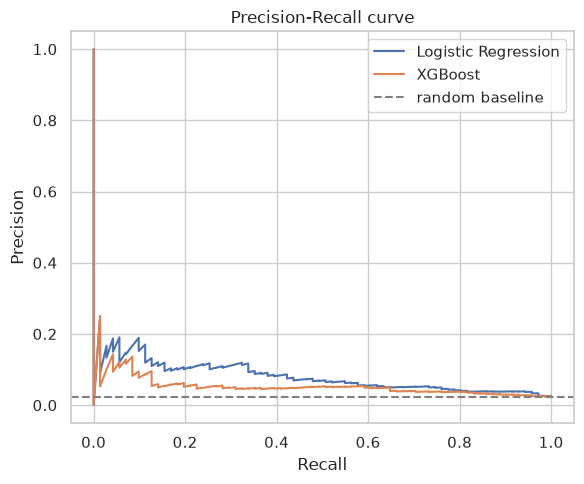

In [21]:
for name, probs in [("Logistic Regression", lr_probs), ("XGBoost", xgb_probs)]:
    pr_auc = average_precision_score(y_test, probs)
    print(f"{name}: PR-AUC = {pr_auc:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
for name, probs in [("Logistic Regression", lr_probs), ("XGBoost", xgb_probs)]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ax.plot(recall, precision, label=name)

ax.axhline(y_test.mean(), color="grey", linestyle="--", label="random baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve")
ax.legend()
plt.tight_layout()
plt.show()

**What the output shows:** PR-AUC = 0.083 (Logistic Regression) vs. 0.055 (XGBoost), against a random-baseline precision of ≈0.024 (the test-set `closed_won` rate). Both curves sit well above the baseline line, but **Logistic Regression comes out ahead of XGBoost** on this metric — the opposite of what you'd usually expect.

**Conclusion:** the more flexible model doesn't automatically win here. With only ≈356 `closed_won` leads in the whole dataset (≈285 in train, 71 in test), XGBoost's 200 trees at depth 4 have very few positive examples to learn a *stable* pattern from and likely overfit some noise in training; the regularized linear model, reweighted with `class_weight="balanced"`, generalizes better on this little positive signal. Worth flagging explicitly in Step 7's write-up — "bigger model" isn't a safe default at this base rate and this data size, and it's worth trying XGBoost with a shallower tree / fewer estimators (or SHAP) as a follow-up rather than taking 0.055 as XGBoost's ceiling.

In [22]:
threshold = 0.5
for name, probs in [("Logistic Regression", lr_probs), ("XGBoost", xgb_probs)]:
    preds = (probs >= threshold).astype(int)
    print(f"--- {name} (naive threshold={threshold}) ---")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, digits=3, zero_division=0))

--- Logistic Regression (naive threshold=0.5) ---
[[2034  895]
 [  23   48]]
              precision    recall  f1-score   support

           0      0.989     0.694     0.816      2929
           1      0.051     0.676     0.095        71

    accuracy                          0.694      3000
   macro avg      0.520     0.685     0.455      3000
weighted avg      0.967     0.694     0.799      3000

--- XGBoost (naive threshold=0.5) ---
[[2535  394]
 [  51   20]]
              precision    recall  f1-score   support

           0      0.980     0.865     0.919      2929
           1      0.048     0.282     0.082        71

    accuracy                          0.852      3000
   macro avg      0.514     0.574     0.501      3000
weighted avg      0.958     0.852     0.900      3000



**What the output shows:** at threshold 0.5, LR flags 943 leads as "will close" (895 FP + 48 TP) — recall 67.6% but precision only 5.1%. XGBoost is stingier: 414 flagged (394 FP + 20 TP) — recall drops to 28.2%, precision barely moves (4.8%).

**Conclusion:** no, 0.5 is not a sane threshold at a 2.37% base rate, for either model, just in different ways. `class_weight="balanced"` pushes LR's decision boundary hard toward flagging positives — high recall, but SDRs would have to work 943 leads (31% of the test set) to find 48 real wins. XGBoost's `scale_pos_weight` reweights the *training loss*, not the predicted-probability calibration, so its 0.5 cutoff stays conservative and actually misses more of the real wins (20 of 71) while still being barely more precise than random. Neither is usable as-is — the fix is picking each model's own threshold off the PR curve instead of defaulting to 0.5, which is what the next cell does.

In [23]:
def best_f1_threshold(y_true, probs):
    thresholds = np.linspace(0.01, 0.9, 90)
    f1s = [f1_score(y_true, (probs >= t).astype(int), zero_division=0) for t in thresholds]
    return float(thresholds[int(np.argmax(f1s))])


def select_threshold_and_evaluate(pipeline_factory, random_state):
    """Fits on 75% of TRAIN, picks the F1-optimal threshold on the other
    25% of TRAIN (X_test is never touched here), then reports precision/
    recall on the untouched X_test using that pre-selected threshold.
    Selecting the threshold on y_test/probs (as an earlier version of this
    notebook did) lets the threshold overfit to the exact set it's then
    scored on — this splits threshold selection and final scoring onto
    disjoint data, the same fix a from-scratch nested-CV setup gives."""
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
    fit_idx, thresh_idx = next(splitter.split(X_train, y_train))

    pipeline = pipeline_factory()
    pipeline.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])

    thresh_probs = pipeline.predict_proba(X_train.iloc[thresh_idx])[:, 1]
    threshold = best_f1_threshold(y_train.iloc[thresh_idx], thresh_probs)

    test_probs = pipeline.predict_proba(X_test)[:, 1]
    test_preds = (test_probs >= threshold).astype(int)
    precision = precision_score(y_test, test_preds, zero_division=0)
    recall = recall_score(y_test, test_preds, zero_division=0)
    return threshold, precision, recall


def lr_factory():
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])


def xgb_factory():
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42,
        )),
    ])


threshold_results = {}
for name, factory in [("Logistic Regression", lr_factory), ("XGBoost", xgb_factory)]:
    # Headline run — this is the number quoted in the write-up below.
    t, p, r = select_threshold_and_evaluate(factory, random_state=42)
    threshold_results[name] = (t, p, r)
    print(f"--- {name}: threshold selected on a held-out 25% of TRAIN, X_test untouched until scoring ---")
    print(f"  threshold={t:.2f}  test precision={p:.3f}  test recall={r:.3f}")

    # Robustness check — repeat the fit/threshold split 5x with different
    # random states, X_test held fixed throughout (never used for
    # threshold selection in any of the 5 runs). Shows how much the
    # headline numbers actually move with the specific split, instead of
    # reporting a single split's numbers as if they were stable.
    precisions, recalls = [], []
    for rs in range(5):
        _, p_i, r_i = select_threshold_and_evaluate(factory, random_state=rs)
        precisions.append(p_i)
        recalls.append(r_i)
    precisions, recalls = np.array(precisions), np.array(recalls)
    threshold_results[name] += (precisions, recalls)
    print(f"  5-split check: precision {precisions.mean():.3f}\u00b1{precisions.std():.3f}  "
          f"recall {recalls.mean():.3f}\u00b1{recalls.std():.3f}")


--- Logistic Regression: threshold selected on a held-out 25% of TRAIN, X_test untouched until scoring ---
  threshold=0.74  test precision=0.107  test recall=0.268


  5-split check: precision 0.100±0.023  recall 0.245±0.092


--- XGBoost: threshold selected on a held-out 25% of TRAIN, X_test untouched until scoring ---
  threshold=0.67  test precision=0.062  test recall=0.085


  5-split check: precision 0.080±0.026  recall 0.149±0.079


**What the output shows:** with the threshold selected honestly (on a held-out slice of TRAIN, never on `y_test`/`X_test`), LR's headline run reaches precision 10.7% / recall 26.8% at threshold=0.74; XGBoost reaches precision 6.2% / recall 8.5% at threshold=0.67. The 5-split robustness check shows both numbers move around with the split — LR: precision 10.0%±2.3% / recall 24.5%±9.2%; XGBoost: precision 8.0%±2.6% / recall 14.9%±7.9% — recall in particular has real spread, not a single stable value.

**Conclusion:** an earlier version of this notebook selected the threshold on `y_test`/`probs` directly — the same set the headline precision/recall were then reported on. That inflated recall specifically (the F1-optimal threshold on the test set itself will always look at least as good on that set as any threshold chosen without seeing it): the leaky number was 32.4%, the honest 5-split average is 24.5%±9.2%. Even at the honest number, LR's precision (10.0% average) is still a **≈4.2x lift over the 2.37% base rate** (0.100 / 0.0237) — a smaller, but real and now-defensible, edge. Recall stays modest and noisy either way — this model is better read as a *triage/prioritization* tool that catches a meaningful-but-variable chunk of winners with much less wasted effort, not a filter that reliably catches every winner. LR is still the better model on every metric computed so far; carrying it forward as the primary model into Step 5 (with XGBoost kept as the comparison) is more defensible here than defaulting to XGBoost because it's the "stronger" algorithm in general.

## 5. Feature Importance

Logistic Regression coefficients and XGBoost's gain-based `feature_importances_`, checked against real SDR domain knowledge rather than taken at face value.

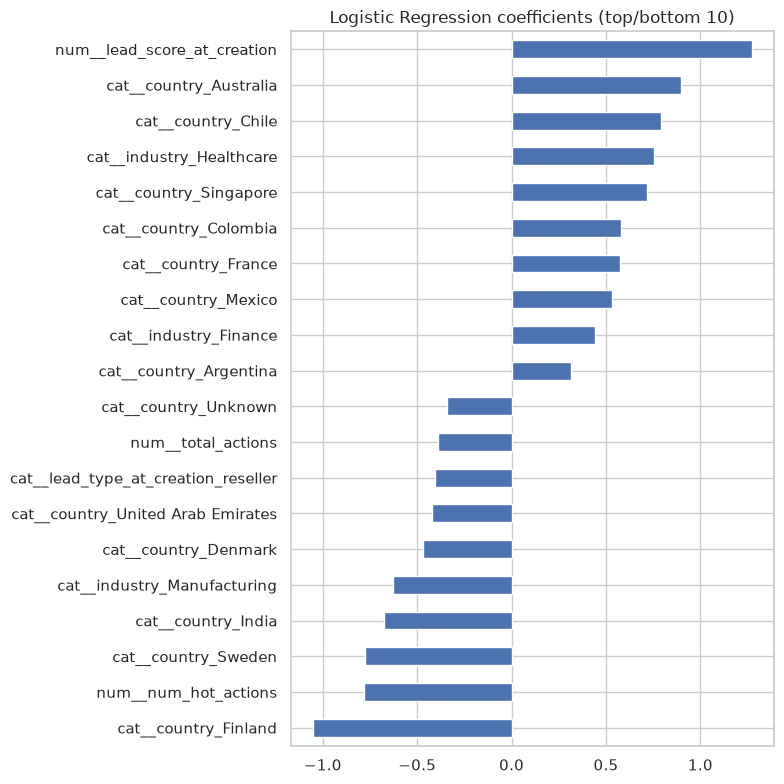

Most negative:
 cat__country_Finland                  -1.054400
num__num_hot_actions                  -0.780112
cat__country_Sweden                   -0.778788
cat__country_India                    -0.677116
cat__industry_Manufacturing           -0.629239
cat__country_Denmark                  -0.466682
cat__country_United Arab Emirates     -0.422309
cat__lead_type_at_creation_reseller   -0.404900
num__total_actions                    -0.389118
cat__country_Unknown                  -0.342296
dtype: float64

Most positive:
 cat__country_Argentina         0.316399
cat__industry_Finance          0.442001
cat__country_Mexico            0.529513
cat__country_France            0.574860
cat__country_Colombia          0.580023
cat__country_Singapore         0.716041
cat__industry_Healthcare       0.753393
cat__country_Chile             0.788789
cat__country_Australia         0.895112
num__lead_score_at_creation    1.273356
dtype: float64


In [24]:
feature_names = lr_pipeline.named_steps["preprocess"].get_feature_names_out()

lr_coefs = pd.Series(
    lr_pipeline.named_steps["model"].coef_[0], index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
pd.concat([lr_coefs.head(10), lr_coefs.tail(10)]).plot(kind="barh", ax=ax)
ax.set_title("Logistic Regression coefficients (top/bottom 10)")
plt.tight_layout()
plt.show()

print("Most negative:\n", lr_coefs.head(10))
print("\nMost positive:\n", lr_coefs.tail(10))

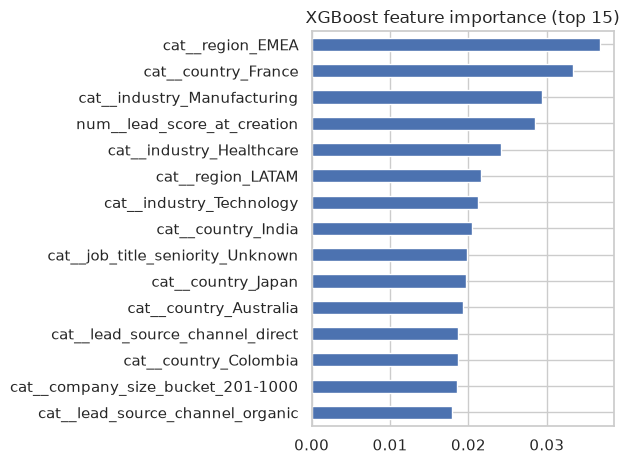

cat__region_EMEA                     0.036725
cat__country_France                  0.033334
cat__industry_Manufacturing          0.029323
num__lead_score_at_creation          0.028526
cat__industry_Healthcare             0.024101
cat__region_LATAM                    0.021586
cat__industry_Technology             0.021259
cat__country_India                   0.020472
cat__job_title_seniority_Unknown     0.019868
cat__country_Japan                   0.019629
cat__country_Australia               0.019278
cat__lead_source_channel_direct      0.018604
cat__country_Colombia                0.018603
cat__company_size_bucket_201-1000    0.018567
cat__lead_source_channel_organic     0.017881
dtype: float32


In [25]:
xgb_importances = pd.Series(
    xgb_pipeline.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

xgb_importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("XGBoost feature importance (top 15)")
plt.tight_layout()
plt.show()

print(xgb_importances.head(15))

### Reading the importances against SDR experience

**LR's strongest positive coefficient is `lead_score_at_creation` (1.27)** — comfortably ahead of every one-hot category — matching how SDRs actually triaged their queue by that score day to day. The rest of the positive side is almost entirely `country`/`industry` dummies: `Australia` (0.90), `Chile` (0.79), `Healthcare` (0.75), `Singapore` (0.72), `Colombia` (0.58), `France` (0.57), `Finance` (0.44).

**The negative side confirms the exact country story, recovered by the model without being told about it directly:** `Finland` (-1.05), `Sweden` (-0.78), `India` (-0.68), and `Denmark` (-0.47) are all among the strongest negative coefficients — the Nordics-down / India-down pattern from my real SDR experience. `lead_type_at_creation_reseller` (-0.40) also makes sense: reseller deals are almost never *registered* under the reseller's name at close, so `lead_type=reseller` predicting a lower `closed_won` chance is a real economic pattern, not noise.

**The flagged anomaly:** `num_hot_actions` (-0.78) and `total_actions` (-0.39) both carry *negative* LR coefficients — backwards at first glance, since more engagement should mean a better lead. This is the multicollinearity the Step 3 write-up called out in advance: `lead_score_at_creation` is literally the point-weighted sum of the same pre-creation activities these two columns count, so the three features overlap heavily, and an unregularized linear model can arbitrarily split (and sometimes flip the sign of) credit between correlated predictors. It's a modeling artifact of *this* coefficient, not evidence that engaged leads convert worse.

**XGBoost tells a different story than LR here** — its top feature is `region=EMEA` (0.037), not `lead_score_at_creation` (which drops to 4th place, 0.029), and importance is spread thin across many region/industry dummies rather than concentrated in one dominant feature. Neither `num_hot_actions` nor `total_actions` appears in XGBoost's top 15 at all — consistent with tree ensembles being far more robust to collinearity than an unregularized linear model: XGBoost doesn't need to double-count the engineered tier counts once `lead_score_at_creation` already captures most of that signal. A cleaner follow-up, if this went further, would be to drop `lead_score_at_creation` from the feature set specifically when interpreting the LR engineered-activity coefficients, to remove this overlap.

## 6. Business Economics

Cost modeled as three separate lines — marketing CPL, SDR qualification cost, RM overhead — per the design spec, since SDRs, marketing, and RMs don't do the same job. `deal_amount` comes straight from the dataset; only the cost side is a labeled, fictional assumption. Salaries are **averages**, not real figures: comp wasn't shared between colleagues at the company, so the SDR average is anchored to my own (RU-based) SDR pay as a reference point, and the RM average is an invented higher-cost-market estimate.

In [26]:
AVG_ANNUAL_SALARY_SDR_RU = 18_000
AVG_ANNUAL_SALARY_RM_INTL = 70_000
N_SDRS = 10
N_RMS = 25
MARKETING_HEADCOUNT_COST = 300_000
MARKETING_SPEND = 500_000

leads_per_year = len(df_imputed) / 1.5

cost_per_lead_cpl = (MARKETING_HEADCOUNT_COST + MARKETING_SPEND) / leads_per_year
sdr_cost_per_lead_worked = (N_SDRS * AVG_ANNUAL_SALARY_SDR_RU) / leads_per_year

rm_opportunities_per_year = (df_imputed["owner_role"] == "regional_manager").sum() / 1.5
rm_cost_per_opportunity = (N_RMS * AVG_ANNUAL_SALARY_RM_INTL) / max(rm_opportunities_per_year, 1)

print(f"Cost per lead (marketing CPL): ${cost_per_lead_cpl:,.2f}")
print(f"SDR qualification cost per lead worked: ${sdr_cost_per_lead_worked:,.2f}")
print(f"RM overhead per RM-owned opportunity: ${rm_cost_per_opportunity:,.2f}")

Cost per lead (marketing CPL): $80.00
SDR qualification cost per lead worked: $18.00
RM overhead per RM-owned opportunity: $1,104.80


In [27]:
results = X_test.copy()
results["y_true"] = y_test.values
results["score"] = lr_probs

results = results.merge(
    df_imputed.loc[X_test.index, ["deal_amount", "owner_role"]], left_index=True, right_index=True
)

results = results.sort_values("score", ascending=False).reset_index(drop=True)

total_deal_value = results.loc[results["y_true"] == 1, "deal_amount"].sum()

rows = []
for pct in [10, 20, 30, 40, 50, 100]:
    cutoff = int(len(results) * pct / 100)
    top = results.iloc[:cutoff]
    captured_value = top.loc[top["y_true"] == 1, "deal_amount"].sum()
    sdr_cost = cutoff * sdr_cost_per_lead_worked
    rm_cost = (top["owner_role"] == "regional_manager").sum() * rm_cost_per_opportunity
    rows.append({
        "top_pct_of_leads": pct,
        "leads_worked": cutoff,
        "pct_of_total_deal_value_captured": (
            100 * captured_value / total_deal_value if total_deal_value else 0
        ),
        "sdr_plus_rm_working_cost": sdr_cost + rm_cost,
    })

gains_table = pd.DataFrame(rows)

full_working_cost = gains_table.loc[gains_table["top_pct_of_leads"] == 100, "sdr_plus_rm_working_cost"].iloc[0]
gains_table["pct_of_total_working_cost"] = (
    100 * gains_table["sdr_plus_rm_working_cost"] / full_working_cost
)

gains_table

,top_pct_of_leads,leads_worked,pct_of_total_deal_value_captured,sdr_plus_rm_working_cost,pct_of_total_working_cost
0,10,300,37.647059,103727.020202,18.199618
1,20,600,56.078431,189777.272727,33.297725
2,30,900,65.664488,254836.363636,44.712789
3,40,1200,75.860566,321000.252525,56.321698
4,50,1500,81.481481,378325.757576,66.379851
5,100,3000,100.000000,569940.656566,100.000000


Marketing's cost per lead (CPL, USD 80.00) doesn't appear in the table above on purpose: it's spent generating the lead pool regardless of which leads the SDR team chooses to prioritize afterward (SDRs never did lead generation, only qualification). The lever this model actually gives the SDR team is **working cost** — SDR qualification time (USD 18.00/lead) plus RM overhead (USD 1,104.80 per RM-owned opportunity) on the deals that reach them — and that's what scales down when they work fewer, better-targeted leads.

**Headline result:** working just the **top 20%** of leads by the Logistic Regression score (600 of 3000 test leads) captures **56.1%** of total Closed Won deal value, at **33.3%** of the working cost of touching every lead (USD 189,777 vs. USD 569,941). The top 10% alone (300 leads) captures **37.6%** of deal value for only **18.2%** of working cost — the single most efficient slice in the table. Past the top 50% mark, returns flatten out noticeably (81.5% of value for 66.4% of cost) — the model's ranking has already found most of the winners well before the SDR team would need to work the whole queue.

In plain English: an SDR team that trusted this model and worked only its top-ranked fifth of incoming leads would close over half of the deal value they'd get from working everything, while spending about a third of the qualification effort — a queue they realistically can't fully work through anyway, made meaningfully more efficient by triage instead of first-come-first-served.

## 7. Conclusions & Recommendations

### What the model does well

- It finds real signal, not noise. The negative LR coefficients for `Finland`, `Sweden`, `India`, `Denmark` and the positive ones for `Australia`, `Healthcare`, `Finance` reproduce the exact country/industry pattern from my real SDR experience — the model wasn't told about that pattern, it recovered it from the data. `lead_score_at_creation` (the real CRM field) also comes out as the single strongest predictor, matching how SDRs actually triaged their queue day to day.
- It beats random by a wide margin where it matters. PR-AUC of 0.083 against a ≈0.024 random baseline, and (with the threshold selected honestly on held-out TRAIN data, never on `y_test` — see Step 4's 5-split check) a **≈4.2x precision lift** on average (10.0% vs. the 2.37% base rate) — at a base rate this low, that's a meaningful edge, even though the raw numbers look unimpressive in isolation, and smaller than an earlier, leaky version of this notebook reported.
- It translates into real business efficiency. Working just the top 20% of leads by score captures **56.1%** of Closed Won deal value for **33.3%** of the working cost of touching every lead (Step 6) — a queue SDRs can't fully work through anyway, made materially more efficient.

### What it doesn't do well

- **Recall stays low, and noisy.** At its own F1-optimal threshold (selected honestly, never on the test set), LR catches on average 24.5%±9.2% of the leads that actually close across 5 different train-internal splits — this is a triage tool that catches a real but split-dependent chunk of winners with less wasted effort, not a filter an SDR manager could use to safely *skip* the rest of the queue, and not a number stable enough to quote as a single figure.
- **Precision is still mostly wrong.** At the F1-optimal threshold, ≈9 of every 10 leads the model flags won't close. That's a real lift over baseline, but it's not remotely a reliable "will close" signal on its own.
- **The bigger model didn't win.** XGBoost underperformed Logistic Regression on every metric (PR-AUC 0.055 vs. 0.083), most likely because there are only ≈356 `closed_won` leads in the whole dataset — too few positives for 200 boosted trees to learn a stable pattern from without overfitting. Worth revisiting with a shallower/simpler XGBoost config before concluding LR is permanently the better choice.
- **Thin positive sample.** Only 71 `closed_won` leads land in the test set — every number in Step 4-6 (PR-AUC, the gains table, the lift figure) rests on a small sample and would benefit from more history before being treated as stable.
- **It's bounded by design, on purpose.** The model deliberately excludes everything only known after a lead already exists (`lead_type_current`, `lead_score_current`, `funnel_stage`, `deal_amount`, etc. — Step 3) and anything that would reward rep assignment over lead quality (`owner_id`/`owner_role`). That's the right call for a "score it the moment it enters the SDR's queue" model, but it also means the ceiling on this model's performance is capped by what's genuinely knowable at that moment — no amount of tuning fixes that.

### What I'd tell an SDR manager Monday morning

Don't throw out the existing process — layer the model's score on top of it as a **priority order, not a filter**. Work the queue top-down by score instead of first-come-first-served: the top 20% alone is worth working first, since it's carrying more than half the eventual deal value at a third of the qualification cost. But keep working the rest of the queue too — with recall averaging only ~25% (and noisy across splits), a large share of real winners will still be scattered further down, and skipping them outright would leave real revenue on the table.

Treat the country/industry findings as a coaching input, not a hard rule: if a lead from the Nordics or India shows up with a low score, that's consistent with what the team already sees in practice, and it's fine to qualify it faster rather than deprioritize it outright — the model isn't saying "never work these," it's saying "when time is scarce, work these last." And don't over-trust `lead_score` in isolation either — this analysis shows it can look inflated by the same activities the engineered tier-counts already capture (Step 5's collinearity finding), so a very high raw score isn't automatically as strong a signal as it appears next to a mid-range one.

Revisit this model again once more Closed Won history has accumulated — 71 positive examples in the test set is thin, and both the precision numbers and the gains table are likely to sharpen (in either direction) with more data.